**Pipeline:**
```
User Input → Retrieve from ChromaDB → Filter Relevant Docs → Generate Answer
          → Hallucination Check → (Revise if needed) → Usefulness Check
          → (Rewrite Query + Re-retrieve if needed) → Final Sponsors
```

## Cell 1 — Install Dependencies

In [ ]:
%pip install langchain langchain-community langchain-core chromadb pandas tqdm python-dotenv sentence-transformers requests langgraph langchain-openai tavily-python scikit-learn matplotlib numpy -q

In [11]:
target_dir = r"C:\Users\KISHORE S\Desktop\agenticai(shristi)"
os.chdir(target_dir)
print("✅ Current working directory:", os.getcwd())

✅ Current working directory: C:\Users\KISHORE S\Desktop\agenticai(shristi)


## Cell 2 — Imports & Environment Setup

In [1]:
import os
import json
import requests
import pandas as pd
from tqdm import tqdm
from dotenv import load_dotenv
from typing import List, TypedDict, Optional, Dict, Any
from IPython.display import Markdown, display

from langchain_core.documents import Document
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import Chroma
from langgraph.graph import StateGraph, END
from tavily import TavilyClient

load_dotenv()

OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY")
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")
VECTOR_DB_PATH = "./sponsor_vector_db"
SPEAKER_VECTOR_DB_PATH = "./speaker_vector_db"
EXHIBITOR_VECTOR_DB_PATH = "./exhibitor_vector_db"
VENUE_VECTOR_DB_PATH = "./venue_vector_db"
COMMUNITY_VECTOR_DB_PATH = "./community_vector_db"
EVENT_OPS_VECTOR_DB_PATH = "./event_ops_vector_db"
EMBED_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
LLM_MODEL = "openai/gpt-oss-120b"

tavily_client = TavilyClient(api_key=TAVILY_API_KEY) if TAVILY_API_KEY else None

print("✅ Imports done")
print(f"🔑 OpenRouter key loaded: {'Yes' if OPENROUTER_API_KEY else 'NO — check .env'}")
print(f"🌐 Tavily key loaded: {'Yes' if TAVILY_API_KEY else 'NO — check .env'}")

✅ Imports done
🔑 OpenRouter key loaded: Yes
🌐 Tavily key loaded: Yes


## Cell 3 — Load & Ingest Sponsor CSV into ChromaDB

Each CSV row is converted to a **natural language document** so embeddings can understand it semantically. Run this once — it persists to disk.

In [2]:
# ── Load CSVs ──────────────────────────────────────────────────────────────
sponsors_df = pd.read_csv("data/sponsors_v2.csv")
events_df   = pd.read_csv("data/events_v2.csv")

# Merge to enrich sponsor rows with event metadata (country, city, category)
merged = sponsors_df.merge(events_df, on="event_name", how="left")

print(f"📄 Total sponsor rows: {len(merged)}")
merged.head(3)

FileNotFoundError: [Errno 2] No such file or directory: 'data/sponsors_v2.csv'

In [ ]:
# ── Convert each row → LangChain Document ─────────────────────────────────
documents = []

for _, row in tqdm(merged.iterrows(), total=len(merged), desc="Building docs"):
    # Natural language text — richer text = better semantic retrieval
    text = (
        f"{row['sponsor_name']} is a {row['industry']} company that sponsored "
        f"{row['event_name']}, a {row.get('category','AI')} conference held in "
        f"{row.get('city','Unknown')}, {row.get('country','Unknown')} in {row.get('year',2025)}. "
        f"They were a {row['tier']} tier sponsor. "
        f"The event had approximately {row.get('attendance','N/A')} attendees."
    )

    doc = Document(
        page_content=text,
        metadata={
            "type":         "sponsor",
            "sponsor_name": row["sponsor_name"],
            "industry":     row["industry"],
            "tier":         row["tier"],
            "event":        row["event_name"],
            "country":      str(row.get("country", "")),
            "category":     str(row.get("category", "")),
        }
    )
    documents.append(doc)

print(f"✅ {len(documents)} documents ready")

Building docs: 100%|██████████| 200/200 [00:00<00:00, 4162.56it/s]

✅ 200 documents ready


In [ ]:
# ── Create embeddings (local, free — no API needed) ────────────────────────
print("⏳ Loading embedding model (downloads once)...")
embedding_fn = HuggingFaceEmbeddings(model_name=EMBED_MODEL)

# ── Store in ChromaDB (persisted to disk) ─────────────────────────────────
print("⏳ Ingesting into ChromaDB...")
vectordb = Chroma.from_documents(
    documents=documents,
    embedding=embedding_fn,
    persist_directory=VECTOR_DB_PATH
)
vectordb.persist()
print(f"✅ ChromaDB saved → {VECTOR_DB_PATH}")

⏳ Loading embedding model (downloads once)...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2973.35it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


⏳ Ingesting into ChromaDB...
✅ ChromaDB saved → ./sponsor_vector_db


In [ ]:
# Unified ingestion cell (optional): builds all six vector DBs in one run
# Creates/refreshes: sponsor_vector_db, speaker_vector_db, exhibitor_vector_db, venue_vector_db, community_vector_db, event_ops_vector_db

from langchain_core.documents import Document

# ---------- 1) Sponsors ----------
sponsors_df = pd.read_csv("data/sponsors_v2.csv")
events_df = pd.read_csv("data/events_v2.csv")
sponsor_merged = sponsors_df.merge(events_df, on="event_name", how="left")

sponsor_docs = []
for _, row in tqdm(sponsor_merged.iterrows(), total=len(sponsor_merged), desc="Sponsor docs"):
    text = (
        f"{row['sponsor_name']} is a {row['industry']} company that sponsored "
        f"{row['event_name']}, a {row.get('category', 'AI')} conference held in "
        f"{row.get('city', 'Unknown')}, {row.get('country', 'Unknown')} in {row.get('year', 2025)}. "
        f"They were a {row['tier']} tier sponsor. "
        f"The event had approximately {row.get('attendance', 'N/A')} attendees."
    )
    sponsor_docs.append(
        Document(
            page_content=text,
            metadata={
                "type": "sponsor",
                "name": str(row.get("sponsor_name", "")),
                "industry": str(row.get("industry", "")),
                "tier": str(row.get("tier", "")),
                "event": str(row.get("event_name", "")),
                "country": str(row.get("country", "")),
                "category": str(row.get("category", "")),
            },
        )
    )

# ---------- 2) Speakers ----------
speakers_df = pd.read_csv("data/speakers_v2.csv")
speaker_merged = speakers_df.merge(events_df, on="event_name", how="left")

speaker_docs = []
for _, row in tqdm(speaker_merged.iterrows(), total=len(speaker_merged), desc="Speaker docs"):
    profile_type = "artist" if str(row.get("designation", "")).lower() in {"artist", "performer", "musician", "dj", "singer", "actor"} else "speaker"
    text = (
        f"{row.get('speaker_name', 'Unknown')} is a {row.get('designation', 'expert')} at {row.get('company', 'Unknown company')}. "
        f"They spoke/performed on {row.get('topic', 'general topic')} at {row.get('event_name', 'Unknown event')}. "
        f"Event category: {row.get('category', 'Unknown')}. "
        f"Location: {row.get('city', 'Unknown')}, {row.get('country', 'Unknown')}. "
        f"Estimated attendance: {row.get('attendance', 'N/A')}. Profile type: {profile_type}."
    )
    speaker_docs.append(
        Document(
            page_content=text,
            metadata={
                "type": "speaker_profile",
                "profile_name": str(row.get("speaker_name", "")),
                "profile_type": profile_type,
                "designation": str(row.get("designation", "")),
                "company": str(row.get("company", "")),
                "topic": str(row.get("topic", "")),
                "event": str(row.get("event_name", "")),
                "country": str(row.get("country", "")),
                "category": str(row.get("category", "")),
            },
        )
    )

# ---------- 3) Exhibitors ----------
exhibitors_df = pd.read_csv("data/exhibitors.csv")
exhibitor_merged = exhibitors_df.merge(
    events_df[["event_name", "category", "country", "city", "year"]],
    on="event_name",
    how="left",
    suffixes=("_exhibitor", "_event"),
)

exhibitor_docs = []
for _, row in tqdm(exhibitor_merged.iterrows(), total=len(exhibitor_merged), desc="Exhibitor docs"):
    text = (
        f"{row.get('company_name', 'Unknown Company')} exhibited at {row.get('event_name', 'Unknown Event')}. "
        f"Exhibitor category: {row.get('category_exhibitor', 'Unknown')}. "
        f"Domain: {row.get('domain', 'Unknown')}. "
        f"Event category: {row.get('category_event', 'Unknown')}. "
        f"Location: {row.get('city', 'Unknown')}, {row.get('country', 'Unknown')}. "
        f"Year: {row.get('year', 'Unknown')}."
    )
    exhibitor_docs.append(
        Document(
            page_content=text,
            metadata={
                "type": "exhibitor",
                "company_name": str(row.get("company_name", "")),
                "exhibitor_category": str(row.get("category_exhibitor", "")),
                "domain": str(row.get("domain", "")),
                "event": str(row.get("event_name", "")),
                "event_category": str(row.get("category_event", "")),
                "country": str(row.get("country", "")),
                "city": str(row.get("city", "")),
                "year": str(row.get("year", "")),
            },
        )
    )

# ---------- 4) Venues ----------
venues_df = pd.read_csv("data/venues.csv")

venue_docs = []
for _, row in tqdm(venues_df.iterrows(), total=len(venues_df), desc="Venue docs"):
    text = (
        f"{row.get('venue_name', 'Unknown Venue')} is located in {row.get('city', 'Unknown')}, {row.get('country', 'Unknown')}. "
        f"Capacity is approximately {row.get('capacity', 'Unknown')} attendees. "
        f"Estimated cost is {row.get('estimated_cost', 'Unknown')}. "
        f"Venue type: {row.get('venue_type', 'Unknown')}. Setup type: {row.get('setup_type', 'Unknown')}. "
        f"Past events hosted: {row.get('past_events', 'N/A')}."
    )
    venue_docs.append(
        Document(
            page_content=text,
            metadata={
                "type": "venue",
                "venue_name": str(row.get("venue_name", "")),
                "city": str(row.get("city", "")),
                "country": str(row.get("country", "")),
                "capacity": str(row.get("capacity", "")),
                "estimated_cost": str(row.get("estimated_cost", "")),
                "past_events": str(row.get("past_events", "")),
                "venue_type": str(row.get("venue_type", "")),
                "setup_type": str(row.get("setup_type", "")),
            },
        )
    )

# ---------- 5) Communities ----------
communities_df = pd.read_csv("data/communities.csv")

community_docs = []
for _, row in tqdm(communities_df.iterrows(), total=len(communities_df), desc="Community docs"):
    text = (
        f"{row.get('community_name', 'Unknown Community')} is a {row.get('platform', 'community platform')} community "
        f"focused on {row.get('category', 'general')} with around {row.get('members_count', 'unknown')} members. "
        f"Engagement score is {row.get('engagement_score', 'unknown')}/10. "
        f"Location focus: {row.get('location_focus', 'Global')}. Link: {row.get('link', 'N/A')}."
    )
    community_docs.append(
        Document(
            page_content=text,
            metadata={
                "type": "community",
                "platform": str(row.get("platform", "")),
                "community_name": str(row.get("community_name", "")),
                "category": str(row.get("category", "")),
                "members_count": str(row.get("members_count", "")),
                "engagement_score": str(row.get("engagement_score", "")),
                "location_focus": str(row.get("location_focus", "")),
                "link": str(row.get("link", "")),
            },
        )
    )

# ---------- 6) Event Ops (agenda, rooms, slots) ----------
sessions_df = pd.read_csv("data/sessions.csv")
rooms_df = pd.read_csv("data/rooms.csv")
time_slots_df = pd.read_csv("data/time_slots.csv")

event_ops_docs = []

# Room inventory docs
for _, row in tqdm(rooms_df.iterrows(), total=len(rooms_df), desc="EventOps room docs"):
    text = (
        f"Room resource: {row.get('room_name', 'Unknown Room')} with capacity {row.get('capacity', 'Unknown')} "
        f"and type {row.get('type', 'Unknown')}."
    )
    event_ops_docs.append(
        Document(
            page_content=text,
            metadata={
                "type": "event_ops_room",
                "room_name": str(row.get("room_name", "")),
                "capacity": str(row.get("capacity", "")),
                "room_type": str(row.get("type", "")),
            },
        )
    )

# Time slot docs
for _, row in tqdm(time_slots_df.iterrows(), total=len(time_slots_df), desc="EventOps slot docs"):
    text = f"Time slot resource from {row.get('start_time', 'NA')} to {row.get('end_time', 'NA')}."
    event_ops_docs.append(
        Document(
            page_content=text,
            metadata={
                "type": "event_ops_slot",
                "start_time": str(row.get("start_time", "")),
                "end_time": str(row.get("end_time", "")),
            },
        )
    )

# Session docs enriched with best-fit room candidates
for _, row in tqdm(sessions_df.iterrows(), total=len(sessions_df), desc="EventOps session docs"):
    expected = float(row.get('expected_audience', 0) or 0)
    room_candidates = rooms_df[rooms_df['capacity'] >= expected].copy()
    if room_candidates.empty:
        room_candidates = rooms_df.copy()
    room_candidates['capacity_gap'] = (room_candidates['capacity'] - expected).abs()
    top_rooms = room_candidates.sort_values('capacity_gap').head(3)['room_name'].tolist()

    text = (
        f"Session {row.get('session_id', 'NA')} on {row.get('topic', 'Unknown')} by {row.get('speaker_name', 'Unknown Speaker')}. "
        f"Track: {row.get('track', 'Unknown')}. Priority: {row.get('priority', 'normal')}. "
        f"Duration: {row.get('duration', 'Unknown')} minutes. Expected audience: {row.get('expected_audience', 'Unknown')}. "
        f"Best-fit room candidates: {', '.join(top_rooms)}."
    )
    event_ops_docs.append(
        Document(
            page_content=text,
            metadata={
                "type": "event_ops_session",
                "session_id": str(row.get("session_id", "")),
                "speaker_name": str(row.get("speaker_name", "")),
                "topic": str(row.get("topic", "")),
                "duration": str(row.get("duration", "")),
                "priority": str(row.get("priority", "")),
                "track": str(row.get("track", "")),
                "expected_audience": str(row.get("expected_audience", "")),
                "room_candidates": ",".join(top_rooms),
            },
        )
    )

# ---------- Persist all DBs ----------
embedding_fn = HuggingFaceEmbeddings(model_name=EMBED_MODEL)

vectordb = Chroma.from_documents(
    documents=sponsor_docs,
    embedding=embedding_fn,
    persist_directory=VECTOR_DB_PATH,
)
vectordb.persist()

speaker_vectordb = Chroma.from_documents(
    documents=speaker_docs,
    embedding=embedding_fn,
    persist_directory=SPEAKER_VECTOR_DB_PATH,
)
speaker_vectordb.persist()

exhibitor_vectordb = Chroma.from_documents(
    documents=exhibitor_docs,
    embedding=embedding_fn,
    persist_directory=EXHIBITOR_VECTOR_DB_PATH,
)
exhibitor_vectordb.persist()

venue_vectordb = Chroma.from_documents(
    documents=venue_docs,
    embedding=embedding_fn,
    persist_directory=VENUE_VECTOR_DB_PATH,
)
venue_vectordb.persist()

community_vectordb = Chroma.from_documents(
    documents=community_docs,
    embedding=embedding_fn,
    persist_directory=COMMUNITY_VECTOR_DB_PATH,
)
community_vectordb.persist()

event_ops_vectordb = Chroma.from_documents(
    documents=event_ops_docs,
    embedding=embedding_fn,
    persist_directory=EVENT_OPS_VECTOR_DB_PATH,
)
event_ops_vectordb.persist()

print("✅ Unified ingestion complete")
print(f"   Sponsors   : {len(sponsor_docs)} -> {VECTOR_DB_PATH}")
print(f"   Speakers   : {len(speaker_docs)} -> {SPEAKER_VECTOR_DB_PATH}")
print(f"   Exhibitors : {len(exhibitor_docs)} -> {EXHIBITOR_VECTOR_DB_PATH}")
print(f"   Venues     : {len(venue_docs)} -> {VENUE_VECTOR_DB_PATH}")
print(f"   Communities: {len(community_docs)} -> {COMMUNITY_VECTOR_DB_PATH}")
print(f"   Event Ops  : {len(event_ops_docs)} -> {EVENT_OPS_VECTOR_DB_PATH}")

Exhibitor docs:   0%|          | 0/200 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3842.10it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Unified ingestion complete
   Sponsors   : 200 -> ./sponsor_vector_db
   Speakers   : 200 -> ./speaker_vector_db
   Exhibitors : 200 -> ./exhibitor_vector_db
   Venues     : 20 -> ./venue_vector_db
   Communities: 20 -> ./community_vector_db
   Event Ops  : 48 -> ./event_ops_vector_db


## Cell 4 — Load Existing ChromaDB (skip ingestion on re-runs)

In [12]:
# Run this cell instead of Cell 3 on subsequent runs
embedding_fn = HuggingFaceEmbeddings(model_name=EMBED_MODEL)

vectordb = Chroma(
    persist_directory=VECTOR_DB_PATH,
    embedding_function=embedding_fn
)

speaker_vectordb = Chroma(
    persist_directory=SPEAKER_VECTOR_DB_PATH,
    embedding_function=embedding_fn
)

exhibitor_vectordb = Chroma(
    persist_directory=EXHIBITOR_VECTOR_DB_PATH,
    embedding_function=embedding_fn
)

venue_vectordb = Chroma(
    persist_directory=VENUE_VECTOR_DB_PATH,
    embedding_function=embedding_fn
)

community_vectordb = Chroma(
    persist_directory=COMMUNITY_VECTOR_DB_PATH,
    embedding_function=embedding_fn
)

event_ops_vectordb = Chroma(
    persist_directory=EVENT_OPS_VECTOR_DB_PATH,
    embedding_function=embedding_fn
)

print(f"✅ Loaded Sponsor ChromaDB from {VECTOR_DB_PATH}")
print(f"   Sponsor documents in DB: {vectordb._collection.count()}")
print(f"✅ Loaded Speaker ChromaDB from {SPEAKER_VECTOR_DB_PATH}")
print(f"   Speaker documents in DB: {speaker_vectordb._collection.count()}")
print(f"✅ Loaded Exhibitor ChromaDB from {EXHIBITOR_VECTOR_DB_PATH}")
print(f"   Exhibitor documents in DB: {exhibitor_vectordb._collection.count()}")
print(f"✅ Loaded Venue ChromaDB from {VENUE_VECTOR_DB_PATH}")
print(f"   Venue documents in DB: {venue_vectordb._collection.count()}")
print(f"✅ Loaded Community ChromaDB from {COMMUNITY_VECTOR_DB_PATH}")
print(f"   Community documents in DB: {community_vectordb._collection.count()}")
print(f"✅ Loaded Event Ops ChromaDB from {EVENT_OPS_VECTOR_DB_PATH}")
print(f"   Event Ops documents in DB: {event_ops_vectordb._collection.count()}")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3828.62it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Loaded Sponsor ChromaDB from ./sponsor_vector_db
   Sponsor documents in DB: 0
✅ Loaded Speaker ChromaDB from ./speaker_vector_db
   Speaker documents in DB: 0
✅ Loaded Exhibitor ChromaDB from ./exhibitor_vector_db
   Exhibitor documents in DB: 0
✅ Loaded Venue ChromaDB from ./venue_vector_db
   Venue documents in DB: 0
✅ Loaded Community ChromaDB from ./community_vector_db
   Community documents in DB: 0
✅ Loaded Event Ops ChromaDB from ./event_ops_vector_db
   Event Ops documents in DB: 0


## Cell 5 — OpenRouter LLM Helper

In [13]:
LLM_MODEL          = "openai/gpt-oss-120b" 

In [14]:
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage
import os
import time
from dotenv import load_dotenv

load_dotenv()

OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY")


llm = ChatOpenAI(
    model=LLM_MODEL,
    openai_api_key=OPENROUTER_API_KEY,
    base_url="https://openrouter.ai/api/v1",
    temperature=0.1,
    max_tokens=4000,
)

def call_llm(prompt: str, temperature: float = 0.1, retries: int = 3) -> str:
    for attempt in range(retries):
        try:
            response = llm.invoke([HumanMessage(content=prompt)])
            return response.content.strip()   # ← AIMessage.content, not .json()

        except Exception as e:
            err = str(e)
            if "429" in err:
                wait = 60 * (attempt + 1)
                print(f"[429] Rate limited. Waiting {wait}s...")
                time.sleep(wait)
            elif "404" in err:
                print("[404] Model not found.")
                return "[LLM ERROR] Model not found"
            elif attempt == retries - 1:
                return f"[LLM ERROR] {e}"
            else:
                time.sleep(10)

    return "[LLM ERROR] Max retries exceeded"

# Test
test = call_llm("Reply with exactly: OK")
print("LLM test:", test)

LLM test: OK


In [15]:
##just to check if the model is working with LangChain's ChatOpenAI wrapper

# from langchain_openai import ChatOpenAI
# from langchain_core.messages import HumanMessage
# import os
# from dotenv import load_dotenv

# # Load API key
# load_dotenv()
# OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY")

# # Initialize LLM
# llm = ChatOpenAI(
#     model=LLM_MODEL,   # or mistral if you want
#     openai_api_key=OPENROUTER_API_KEY,
#     base_url="https://openrouter.ai/api/v1",
#     temperature=0.1,
#     max_tokens=200
# )

# # Test prompt
# response = llm.invoke([
#     HumanMessage(content="Reply with exactly: OK")
# ])

# print("LLM Response:", response.json()["choices"][0]["message"]["content"].strip())

## Cell 6 — Graph State Definition

LangGraph passes a **single shared state dict** through every node. All nodes read from it and write back to it.

In [16]:
class GraphState(TypedDict):
    # -- Inputs --
    user_input: dict  # sponsor/speaker/exhibitor/venue/pricing/community/event_ops request

    # -- Router --
    selected_agent: str  # SPONSOR or SPEAKER or EXHIBITOR or VENUE or PRICING or COMMUNITY or EVENT_OPS

    # -- Retrieval --
    retrieval_query: str
    raw_docs: List[str]
    relevant_docs: List[str]
    web_profiles: List[Dict[str, Any]]
    context: str

    # -- Generation --
    sponsors_answer: str
    pricing: Dict[str, Any]

    # -- Self-RAG control --
    hallucination_verdict: str
    usefulness_verdict: str
    revise_count: int
    rewrite_count: int

print("✅ GraphState defined")

✅ GraphState defined


## Cell 7 — Node Functions

Every node is a plain Python function: `(state) → dict of updates`.

In [17]:
# ═══════════════════════════════════════════════════════════════════════════
# NODE 0 — agent_router
# LLM decides whether to run Sponsor, Speaker, Exhibitor, or Venue flow.
# ═══════════════════════════════════════════════════════════════════════════
def agent_router(state: GraphState) -> dict:
    ui = state["user_input"]
    prompt = (
        "You are an intent router for event-planning agents.\n\n"
        f"User request: {ui}\n\n"
        "Choose exactly one agent:\n"
        "- SPONSOR: sponsors, sponsorship proposal, sponsor prioritization\n"
        "- SPEAKER: speakers, artists, agenda mapping, thought leaders\n"
        "- EXHIBITOR: exhibitors, expo booths, companies to invite for exhibition\n"
        "- VENUE: venue shortlisting, city, capacity, footfall, budget, rental pricing\n\n"
        "Reply with ONLY one token: SPONSOR or SPEAKER or EXHIBITOR or VENUE"
    )
    decision = call_llm(prompt, temperature=0.0).upper().strip()
    if "SPEAKER" in decision:
        selected_agent = "SPEAKER"
    elif "EXHIBITOR" in decision:
        selected_agent = "EXHIBITOR"
    elif "VENUE" in decision:
        selected_agent = "VENUE"
    else:
        selected_agent = "SPONSOR"
    print(f"[agent_router] selected -> {selected_agent}")
    return {"selected_agent": selected_agent}


# ═══════════════════════════════════════════════════════════════════════════
# SHARED SEARCH HELPER
# ═══════════════════════════════════════════════════════════════════════════
def tavily_search(query: str, max_results: int = 5) -> List[Dict[str, str]]:
    if tavily_client is None:
        return [{"title": "search_error", "url": "", "snippet": "Missing TAVILY_API_KEY"}]

    try:
        response = tavily_client.search(
            query=query,
            max_results=max_results,
            include_answer=False,
            include_raw_content=False,
            search_depth="advanced"
        )
        results = response.get("results", [])
        hits: List[Dict[str, str]] = []
        for r in results:
            hits.append({
                "title": r.get("title", ""),
                "url": r.get("url", ""),
                "snippet": r.get("content", "")
            })
        return hits
    except Exception as e:
        return [{"title": "search_error", "url": "", "snippet": str(e)}]


# ═══════════════════════════════════════════════════════════════════════════
# SPONSOR FLOW
# ═══════════════════════════════════════════════════════════════════════════
def build_query(state: GraphState) -> dict:
    ui = state["user_input"]
    query = (
        f"{ui.get('category', 'conference')} conference sponsors in {ui.get('location', 'global')} "
        f"audience size {ui.get('audience_size', 'large')} "
        f"budget {ui.get('budget', 'medium')} "
        "recent sponsorships in last 12 months and marketing spend signals"
    )
    print(f"[build_query] -> '{query}'")
    return {"retrieval_query": query}


def retrieve(state: GraphState) -> dict:
    results = vectordb.similarity_search(state["retrieval_query"], k=18)
    docs = [r.page_content for r in results]
    print(f"[retrieve] sponsor docs={len(docs)}")
    return {"raw_docs": docs}


def filter_relevance(state: GraphState) -> dict:
    relevant = []
    for doc in state["raw_docs"]:
        prompt = (
            "You are evaluating sponsor data relevance for an event.\n\n"
            f"Event details: {state['user_input']}\n\n"
            f"Sponsor info: {doc}\n\n"
            "Is this sponsor relevant to the event described? Reply ONLY with YES or NO."
        )
        verdict = call_llm(prompt, temperature=0.0)
        if "YES" in verdict.upper():
            relevant.append(doc)

    if not relevant:
        relevant = state["raw_docs"][:6]
        print("[filter_relevance] fallback -> top 6 raw docs")
    else:
        print(f"[filter_relevance] relevant={len(relevant)}")

    context = "\n\n".join(relevant)
    return {"relevant_docs": relevant, "context": context}


def enrich_with_web(state: GraphState) -> dict:
    ui = state["user_input"]
    topic = ui.get("category", "conference")
    location = ui.get("location", "global")

    candidates = []
    seen = set()
    for doc in state["relevant_docs"]:
        sponsor_name = doc.split(" is a ")[0].strip()
        if sponsor_name and sponsor_name not in seen:
            seen.add(sponsor_name)
            candidates.append(sponsor_name)

    web_profiles = []
    for sponsor in candidates[:8]:
        q = (
            f"{sponsor} sponsorship {topic} {location} last 12 months "
            "marketing budget campaign announcement"
        )
        hits = tavily_search(q, max_results=5)
        joined = " ".join(h.get("snippet", "") for h in hits).lower()

        web_profiles.append({
            "name": sponsor,
            "kind": "sponsor",
            "query": q,
            "hits": hits,
            "marketing_spend_signal": joined.count("marketing") + joined.count("campaign") + joined.count("budget"),
            "recent_activity_signal": joined.count("2025") + joined.count("2026") + joined.count("recent"),
            "activity_signal": joined.count("sponsor") + joined.count("partnership") + joined.count("conference")
        })

    print(f"[enrich_with_web] sponsor web profiles={len(web_profiles)}")
    return {"web_profiles": web_profiles}


def generate(state: GraphState) -> dict:
    prompt = (
        "You are an expert sponsorship strategist.\n\n"
        f"Event details: {state['user_input']}\n\n"
        "Internal sponsor data (primary grounding):\n"
        f"{state['context']}\n\n"
        "External web evidence from Tavily (secondary grounding):\n"
        f"{json.dumps(state.get('web_profiles', []), ensure_ascii=True, indent=2)}\n\n"
        "Task:\n"
        "Recommend top sponsors and output strict markdown tables:\n"
        "1) Sponsor Prioritization Table\n"
        "| Rank | Sponsor | Industry | Geography Fit | Sponsorship Frequency | Marketing Spend Signal | Priority Score (/100) | Why Selected |\n"
        "2) Custom Sponsorship Proposal Table\n"
        "| Sponsor | Recommended Tier | Proposal Theme | Key Audience Benefit | Suggested Deliverables | Estimated Ask |"
    )
    answer = call_llm(prompt)
    print("[generate] sponsor answer generated")
    return {"sponsors_answer": answer}


# ═══════════════════════════════════════════════════════════════════════════
# SPEAKER FLOW
# ═══════════════════════════════════════════════════════════════════════════
def build_speaker_query(state: GraphState) -> dict:
    ui = state["user_input"]
    query = (
        f"{ui.get('event_topic', ui.get('category', 'AI'))} speaker artist candidates in {ui.get('location', 'global')} "
        f"audience size {ui.get('audience_size', 'large')} with strong influence and keynote experience"
    )
    print(f"[build_speaker_query] -> '{query}'")
    return {"retrieval_query": query}


def retrieve_speaker(state: GraphState) -> dict:
    results = speaker_vectordb.similarity_search(state["retrieval_query"], k=18)
    docs = [r.page_content for r in results]
    print(f"[retrieve_speaker] docs={len(docs)}")
    return {"raw_docs": docs}


def filter_speaker_relevance(state: GraphState) -> dict:
    relevant = []
    for doc in state["raw_docs"]:
        prompt = (
            "You are evaluating speaker/artist profile relevance for an event.\n\n"
            f"Event details: {state['user_input']}\n\n"
            f"Profile info: {doc}\n\n"
            "Is this profile relevant to the event described? Reply ONLY with YES or NO."
        )
        verdict = call_llm(prompt, temperature=0.0)
        if "YES" in verdict.upper():
            relevant.append(doc)

    if not relevant:
        relevant = state["raw_docs"][:6]

    context = "\n\n".join(relevant)
    print(f"[filter_speaker_relevance] relevant={len(relevant)}")
    return {"relevant_docs": relevant, "context": context}


def enrich_speaker_with_web(state: GraphState) -> dict:
    ui = state["user_input"]
    topic = ui.get("event_topic", ui.get("category", "AI"))

    candidates = []
    seen = set()
    for doc in state["relevant_docs"]:
        name = doc.split(" is a ")[0].strip()
        if name and name not in seen:
            seen.add(name)
            candidates.append(name)

    web_profiles = []
    for name in candidates[:8]:
        q = f"{name} LinkedIn {topic} speaker profile followers publications keynote"
        hits = tavily_search(q, max_results=5)
        joined = " ".join(h.get("snippet", "") for h in hits).lower()

        web_profiles.append({
            "name": name,
            "kind": "speaker",
            "query": q,
            "hits": hits,
            "influence_signal_score": (
                joined.count("followers") + joined.count("published") + joined.count("author") +
                joined.count("keynote") + joined.count("speaker")
            )
        })

    print(f"[enrich_speaker_with_web] speaker web profiles={len(web_profiles)}")
    return {"web_profiles": web_profiles}


def generate_speaker(state: GraphState) -> dict:
    prompt = (
        "You are an event programming strategist.\n\n"
        f"Event details: {state['user_input']}\n\n"
        "Internal speaker/artist context:\n"
        f"{state['context']}\n\n"
        "Tavily web evidence:\n"
        f"{json.dumps(state.get('web_profiles', []), ensure_ascii=True, indent=2)}\n\n"
        "Task:\n"
        "Recommend top speakers/artists and output strict markdown tables:\n"
        "1) Speaker/Artist Prioritization Table\n"
        "| Rank | Name | Type | Topic Fit | Past Experience Evidence | Influence Signals | Recommended Session | Priority Score (/100) |\n"
        "2) Agenda Mapping Table\n"
        "| Agenda Slot | Topic | Speaker/Artist | Session Format | Why This Match |"
    )
    answer = call_llm(prompt)
    print("[generate_speaker] speaker answer generated")
    return {"sponsors_answer": answer}


# ═══════════════════════════════════════════════════════════════════════════
# EXHIBITOR FLOW
# ═══════════════════════════════════════════════════════════════════════════
def build_exhibitor_query(state: GraphState) -> dict:
    ui = state["user_input"]
    query = (
        f"companies that exhibited at {ui.get('category', 'technology')} conferences in {ui.get('location', 'global')} "
        "last 12 months startup enterprise tools individual exhibitor"
    )
    print(f"[build_exhibitor_query] -> '{query}'")
    return {"retrieval_query": query}


def retrieve_exhibitor(state: GraphState) -> dict:
    results = exhibitor_vectordb.similarity_search(state["retrieval_query"], k=20)
    docs = [r.page_content for r in results]
    print(f"[retrieve_exhibitor] docs={len(docs)}")
    return {"raw_docs": docs}


def filter_exhibitor_relevance(state: GraphState) -> dict:
    relevant = []
    for doc in state["raw_docs"]:
        prompt = (
            "You are evaluating exhibitor relevance for an event expo hall.\n\n"
            f"Event details: {state['user_input']}\n\n"
            f"Company info: {doc}\n\n"
            "Is this company a suitable potential exhibitor? Reply ONLY with YES or NO."
        )
        verdict = call_llm(prompt, temperature=0.0)
        if "YES" in verdict.upper():
            relevant.append(doc)

    if not relevant:
        relevant = state["raw_docs"][:8]

    context = "\n\n".join(relevant)
    print(f"[filter_exhibitor_relevance] relevant={len(relevant)}")
    return {"relevant_docs": relevant, "context": context}


def enrich_exhibitor_with_web(state: GraphState) -> dict:
    ui = state["user_input"]
    category = ui.get("category", "technology")
    location = ui.get("location", "global")

    candidates = []
    seen = set()
    for doc in state["relevant_docs"]:
        marker = " exhibited at "
        name = doc.split(marker)[0].strip() if marker in doc else doc[:60].strip()
        if name and name not in seen:
            seen.add(name)
            candidates.append(name)

    web_profiles = []
    for name in candidates[:10]:
        q = (
            f"{name} exhibited at conference expo {category} {location} "
            "startup enterprise tools individual"
        )
        hits = tavily_search(q, max_results=5)
        joined = " ".join(h.get("snippet", "") for h in hits).lower()

        web_profiles.append({
            "name": name,
            "kind": "exhibitor",
            "query": q,
            "hits": hits,
            "exhibit_signal": joined.count("exhibit") + joined.count("booth") + joined.count("expo"),
            "startup_signal": joined.count("startup"),
            "enterprise_signal": joined.count("enterprise"),
            "tools_signal": joined.count("platform") + joined.count("tool") + joined.count("saas"),
        })

    print(f"[enrich_exhibitor_with_web] exhibitor web profiles={len(web_profiles)}")
    return {"web_profiles": web_profiles}


def generate_exhibitor(state: GraphState) -> dict:
    prompt = (
        "You are an exhibition planning strategist.\n\n"
        f"Event details: {state['user_input']}\n\n"
        "Internal company context:\n"
        f"{state['context']}\n\n"
        "Tavily web evidence:\n"
        f"{json.dumps(state.get('web_profiles', []), ensure_ascii=True, indent=2)}\n\n"
        "Task:\n"
        "1) Identify companies that exhibited at similar conferences/events.\n"
        "2) Suggest top potential exhibitors for this event.\n"
        "3) Cluster exhibitors by category: startup, enterprise, tools, individual.\n\n"
        "Output strict markdown with tables:\n"
        "A) Exhibitor Recommendation Table\n"
        "| Rank | Company | Why Relevant | Recent Exhibition Evidence | Priority Score (/100) |\n"
        "B) Exhibitor Cluster Table\n"
        "| Cluster Category | Companies | Rationale |"
    )
    answer = call_llm(prompt)
    print("[generate_exhibitor] exhibitor answer generated")
    return {"sponsors_answer": answer}


# ═══════════════════════════════════════════════════════════════════════════
# VENUE FLOW
# ═══════════════════════════════════════════════════════════════════════════
def build_venue_query(state: GraphState) -> dict:
    ui = state["user_input"]
    query = (
        f"venues in {ui.get('location', 'global')} for {ui.get('category', 'conference')} events "
        f"capacity around {ui.get('audience_size', ui.get('expected_footfall', '2000'))} "
        f"budget {ui.get('budget', 'medium')} setup type and past event usage"
    )
    print(f"[build_venue_query] -> '{query}'")
    return {"retrieval_query": query}


def retrieve_venue(state: GraphState) -> dict:
    results = venue_vectordb.similarity_search(state["retrieval_query"], k=15)
    docs = [r.page_content for r in results]
    print(f"[retrieve_venue] docs={len(docs)}")
    return {"raw_docs": docs}


def filter_venue_relevance(state: GraphState) -> dict:
    relevant = []
    for doc in state["raw_docs"]:
        prompt = (
            "You are evaluating venue relevance for an event.\n\n"
            f"Event details: {state['user_input']}\n\n"
            f"Venue info: {doc}\n\n"
            "Is this venue suitable based on city, expected footfall, and budget constraints? Reply ONLY with YES or NO."
        )
        verdict = call_llm(prompt, temperature=0.0)
        if "YES" in verdict.upper():
            relevant.append(doc)

    if not relevant:
        relevant = state["raw_docs"][:6]
        print("[filter_venue_relevance] fallback -> top 6 raw docs")
    else:
        print(f"[filter_venue_relevance] relevant={len(relevant)}")

    context = "\n\n".join(relevant)
    return {"relevant_docs": relevant, "context": context}


def enrich_venue_with_web(state: GraphState) -> dict:
    ui = state["user_input"]
    location = ui.get("location", "global")

    candidates = []
    seen = set()
    for doc in state["relevant_docs"]:
        marker = " is located in "
        name = doc.split(marker)[0].strip() if marker in doc else doc[:60].strip()
        if name and name not in seen:
            seen.add(name)
            candidates.append(name)

    web_profiles = []
    for venue in candidates[:8]:
        q = (
            f"{venue} {location} venue rental pricing capacity events hosted "
            "conference expo reviews"
        )
        hits = tavily_search(q, max_results=5)
        joined = " ".join(h.get("snippet", "") for h in hits).lower()

        web_profiles.append({
            "name": venue,
            "kind": "venue",
            "query": q,
            "hits": hits,
            "pricing_signal": joined.count("price") + joined.count("cost") + joined.count("rental"),
            "capacity_signal": joined.count("capacity") + joined.count("attendees") + joined.count("seating"),
            "event_history_signal": joined.count("hosted") + joined.count("conference") + joined.count("expo"),
        })

    print(f"[enrich_venue_with_web] venue web profiles={len(web_profiles)}")
    return {"web_profiles": web_profiles}


def generate_venue(state: GraphState) -> dict:
    prompt = (
        "You are an event venue selection strategist.\n\n"
        f"Event details: {state['user_input']}\n\n"
        "Internal venue context (primary grounding):\n"
        f"{state['context']}\n\n"
        "External web evidence from Tavily (secondary grounding):\n"
        f"{json.dumps(state.get('web_profiles', []), ensure_ascii=True, indent=2)}\n\n"
        "Task:\n"
        "Recommend top venues and output strict markdown tables:\n"
        "1) Venue Recommendation Table\n"
        "| Rank | Venue | City | Capacity | Estimated Cost | Budget Fit | Footfall Fit | Past Event Usage | Priority Score (/100) |\n"
        "2) Venue Shortlist Rationale Table\n"
        "| Venue | Best For | Setup Type | Key Strength | Potential Constraint |"
    )
    answer = call_llm(prompt)
    print("[generate_venue] venue answer generated")
    return {"sponsors_answer": answer}


# ═══════════════════════════════════════════════════════════════════════════
# SHARED SELF-RAG QUALITY NODES
# ═══════════════════════════════════════════════════════════════════════════
def check_hallucination(state: GraphState) -> dict:
    prompt = (
        "You are a fact-checker.\n\n"
        "Context (ground truth):\n"
        f"{state['context']}\n\n"
        "Web evidence:\n"
        f"{json.dumps(state.get('web_profiles', []), ensure_ascii=True, indent=2)}\n\n"
        "Answer to verify:\n"
        f"{state['sponsors_answer']}\n\n"
        "Is the answer fully supported by the context, partially supported, or not supported?\n"
        "Reply ONLY with one of: Fully Supported / Partially Supported / No Support"
    )
    verdict = call_llm(prompt, temperature=0.0)
    print(f"[check_hallucination] verdict: {verdict}")
    return {"hallucination_verdict": verdict}


def revise(state: GraphState) -> dict:
    prompt = (
        "The following recommendation contains unsupported claims.\n\n"
        "Context (only use this):\n"
        f"{state['context']}\n\n"
        "Web evidence (only use this):\n"
        f"{json.dumps(state.get('web_profiles', []), ensure_ascii=True, indent=2)}\n\n"
        "Original answer:\n"
        f"{state['sponsors_answer']}\n\n"
        "Rewrite using ONLY grounded information and preserve markdown table format."
    )
    revised = call_llm(prompt)
    new_count = state.get("revise_count", 0) + 1
    print(f"[revise] revision #{new_count}")
    return {"sponsors_answer": revised, "revise_count": new_count}


def check_usefulness(state: GraphState) -> dict:
    prompt = (
        "You are evaluating the quality of an event recommendation.\n\n"
        f"Event details: {state['user_input']}\n\n"
        f"Recommendation:\n{state['sponsors_answer']}\n\n"
        "Is this recommendation useful and actionable for the organizer? "
        "Reply ONLY with: Useful / Not Useful"
    )
    verdict = call_llm(prompt, temperature=0.0)
    print(f"[check_usefulness] verdict: {verdict}")
    return {"usefulness_verdict": verdict}


def rewrite_query(state: GraphState) -> dict:
    prompt = (
        "The following query did not retrieve useful information.\n\n"
        f"Original query: {state['retrieval_query']}\n"
        f"Event details: {state['user_input']}\n\n"
        "Write an improved, more specific search query. Return ONLY the query string."
    )
    new_query = call_llm(prompt, temperature=0.5)
    new_count = state.get("rewrite_count", 0) + 1
    print(f"[rewrite_query] new query: '{new_query}' (attempt #{new_count})")
    return {"retrieval_query": new_query, "rewrite_count": new_count}


print("✅ All node functions defined")

✅ All node functions defined


## Cell 7B — Exhibitor Ingestion and ChromaDB Setup

In [18]:
EXHIBITORS_CSV_PATH = "data/exhibitors.csv"
EVENTS_CSV_PATH = "data/events_v2.csv"


# -- Ingest exhibitors into dedicated ChromaDB (run once) --
exhibitors_df = pd.read_csv(EXHIBITORS_CSV_PATH)
events_meta_df = pd.read_csv(EVENTS_CSV_PATH)[["event_name", "category", "country", "city", "year"]]

# category_exhibitor -> startup/tools/enterprise/individual from exhibitors.csv
# category_event    -> conference category from events_v2.csv
exhibitor_merged = exhibitors_df.merge(
    events_meta_df,
    on="event_name",
    how="left",
    suffixes=("_exhibitor", "_event")
)

exhibitor_docs: List[Document] = []
for _, row in tqdm(exhibitor_merged.iterrows(), total=len(exhibitor_merged), desc="Building exhibitor docs"):
    text = (
        f"{row.get('company_name', 'Unknown Company')} exhibited at {row.get('event_name', 'Unknown Event')}. "
        f"Exhibitor category: {row.get('category_exhibitor', 'Unknown')}. "
        f"Domain: {row.get('domain', 'Unknown')}. "
        f"Event category: {row.get('category_event', 'Unknown')}. "
        f"Location: {row.get('city', 'Unknown')}, {row.get('country', 'Unknown')}. "
        f"Year: {row.get('year', 'Unknown')}."
    )

    exhibitor_docs.append(
        Document(
            page_content=text,
            metadata={
                "type": "exhibitor",
                "company_name": str(row.get("company_name", "")),
                "exhibitor_category": str(row.get("category_exhibitor", "")),
                "domain": str(row.get("domain", "")),
                "event": str(row.get("event_name", "")),
                "event_category": str(row.get("category_event", "")),
                "country": str(row.get("country", "")),
                "city": str(row.get("city", "")),
                "year": str(row.get("year", "")),
            },
        )
    )

print(f"✅ Exhibitor docs prepared: {len(exhibitor_docs)}")

# Fresh build for exhibitor vector DB
embedding_fn = HuggingFaceEmbeddings(model_name=EMBED_MODEL)
exhibitor_vectordb = Chroma.from_documents(
    documents=exhibitor_docs,
    embedding=embedding_fn,
    persist_directory=EXHIBITOR_VECTOR_DB_PATH,
)
exhibitor_vectordb.persist()
print(f"✅ Exhibitor ChromaDB saved -> {EXHIBITOR_VECTOR_DB_PATH}")
print(f"   Exhibitor docs in DB: {exhibitor_vectordb._collection.count()}")


# -- Override exhibitor nodes to use exhibitor_vectordb retrieval like other agents --
def build_exhibitor_query(state: GraphState) -> dict:
    ui = state["user_input"]
    query = (
        f"companies that exhibited at {ui.get('category', 'technology')} conferences in {ui.get('location', 'global')} "
        "last 12 months startup enterprise tools individual exhibitor"
    )
    print(f"[build_exhibitor_query] -> '{query}'")
    return {"retrieval_query": query}


def retrieve_exhibitor(state: GraphState) -> dict:
    results = exhibitor_vectordb.similarity_search(state["retrieval_query"], k=20)
    docs = [r.page_content for r in results]
    print(f"[retrieve_exhibitor] docs from exhibitor_vectordb={len(docs)}")
    return {"raw_docs": docs}


def filter_exhibitor_relevance(state: GraphState) -> dict:
    relevant = []
    for doc in state["raw_docs"]:
        prompt = (
            "You are evaluating exhibitor relevance for an event expo hall.\n\n"
            f"Event details: {state['user_input']}\n\n"
            f"Company info: {doc}\n\n"
            "Is this company a suitable potential exhibitor? Reply ONLY with YES or NO."
        )
        verdict = call_llm(prompt, temperature=0.0)
        if "YES" in verdict.upper():
            relevant.append(doc)

    if not relevant:
        relevant = state["raw_docs"][:8]

    context = "\n\n".join(relevant)
    print(f"[filter_exhibitor_relevance] relevant={len(relevant)}")
    return {"relevant_docs": relevant, "context": context}


def enrich_exhibitor_with_web(state: GraphState) -> dict:
    ui = state["user_input"]
    category = ui.get("category", "technology")
    location = ui.get("location", "global")

    candidates = []
    seen = set()
    for doc in state["relevant_docs"]:
        marker = " exhibited at "
        name = doc.split(marker)[0].strip() if marker in doc else doc[:60].strip()
        if name and name not in seen:
            seen.add(name)
            candidates.append(name)

    web_profiles = []
    for name in candidates[:10]:
        q = (
            f"{name} exhibited at conference expo {category} {location} "
            "startup enterprise tools individual"
        )
        hits = tavily_search(q, max_results=5)
        joined = " ".join(h.get("snippet", "") for h in hits).lower()

        web_profiles.append({
            "name": name,
            "kind": "exhibitor",
            "query": q,
            "hits": hits,
            "exhibit_signal": joined.count("exhibit") + joined.count("booth") + joined.count("expo"),
            "startup_signal": joined.count("startup"),
            "enterprise_signal": joined.count("enterprise"),
            "tools_signal": joined.count("platform") + joined.count("tool") + joined.count("saas"),
        })

    print(f"[enrich_exhibitor_with_web] exhibitor web profiles={len(web_profiles)}")
    return {"web_profiles": web_profiles}


print("✅ Exhibitor agent now matches sponsor/speaker flow with Chroma RAG")

Building exhibitor docs: 100%|██████████| 200/200 [00:00<00:00, 12877.81it/s]

✅ Exhibitor docs prepared: 200



Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3629.91it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Exhibitor ChromaDB saved -> ./exhibitor_vector_db
   Exhibitor docs in DB: 200
✅ Exhibitor agent now matches sponsor/speaker flow with Chroma RAG


C:\Users\KISHORE S\AppData\Local\Temp\ipykernel_30372\4246425036.py:55: LangChainDeprecationWarning: Since Chroma 0.4.x the manual persistence method is no longer supported as docs are automatically persisted.
  exhibitor_vectordb.persist()


## Cell 8 — Routing Functions (Conditional Edges)

These decide which node to go to next based on the current state.

In [19]:
MAX_REVISIONS = 1   # max hallucination correction loops
MAX_REWRITES  = 1   # max query rewrite loops


def route_after_agent_router(state: GraphState) -> str:
    agent = state.get("selected_agent", "SPONSOR").upper()
    if "SPEAKER" in agent:
        return "build_speaker_query"
    if "EXHIBITOR" in agent:
        return "build_exhibitor_query"
    if "VENUE" in agent:
        return "build_venue_query"
    return "build_query"


def route_after_hallucination_check(state: GraphState) -> str:
    """
    After hallucination check:
      - Fully Supported  -> proceed to usefulness check
      - Otherwise + retries left -> revise the answer
      - Otherwise + no retries   -> proceed anyway (best effort)
    """
    verdict = state.get("hallucination_verdict", "").upper()
    if "FULLY" in verdict:
        return "check_usefulness"
    if state.get("revise_count", 0) < MAX_REVISIONS:
        return "revise"
    return "check_usefulness"


def route_after_usefulness_check(state: GraphState) -> str:
    """
    After usefulness check:
      - Useful             -> done
      - Not Useful + retries left -> rewrite query and retrieve again
      - Not Useful + no retries   -> done (best effort)
    """
    verdict = state.get("usefulness_verdict", "").upper()
    if "NOT USEFUL" in verdict and state.get("rewrite_count", 0) < MAX_REWRITES:
        return "rewrite_query"
    return END


def route_after_rewrite(state: GraphState) -> str:
    agent = state.get("selected_agent", "SPONSOR").upper()
    if "SPEAKER" in agent:
        return "retrieve_speaker"
    if "EXHIBITOR" in agent:
        return "retrieve_exhibitor"
    if "VENUE" in agent:
        return "retrieve_venue"
    return "retrieve"


print("✅ Routing functions defined")

✅ Routing functions defined


## Cell 9 — Build & Compile the LangGraph

In [20]:
builder = StateGraph(GraphState)

# -- Register nodes --
builder.add_node("agent_router", agent_router)

# Sponsor path
builder.add_node("build_query", build_query)
builder.add_node("retrieve", retrieve)
builder.add_node("filter_relevance", filter_relevance)
builder.add_node("enrich_with_web", enrich_with_web)
builder.add_node("generate", generate)

# Speaker path
builder.add_node("build_speaker_query", build_speaker_query)
builder.add_node("retrieve_speaker", retrieve_speaker)
builder.add_node("filter_speaker_relevance", filter_speaker_relevance)
builder.add_node("enrich_speaker_with_web", enrich_speaker_with_web)
builder.add_node("generate_speaker", generate_speaker)

# Exhibitor path
builder.add_node("build_exhibitor_query", build_exhibitor_query)
builder.add_node("retrieve_exhibitor", retrieve_exhibitor)
builder.add_node("filter_exhibitor_relevance", filter_exhibitor_relevance)
builder.add_node("enrich_exhibitor_with_web", enrich_exhibitor_with_web)
builder.add_node("generate_exhibitor", generate_exhibitor)

# Venue path
builder.add_node("build_venue_query", build_venue_query)
builder.add_node("retrieve_venue", retrieve_venue)
builder.add_node("filter_venue_relevance", filter_venue_relevance)
builder.add_node("enrich_venue_with_web", enrich_venue_with_web)
builder.add_node("generate_venue", generate_venue)

# Shared quality path
builder.add_node("check_hallucination", check_hallucination)
builder.add_node("revise", revise)
builder.add_node("check_usefulness", check_usefulness)
builder.add_node("rewrite_query", rewrite_query)

# -- Entry point --
builder.set_entry_point("agent_router")

# -- Agent-router branching --
builder.add_conditional_edges(
    "agent_router",
    route_after_agent_router,
    {
        "build_query": "build_query",
        "build_speaker_query": "build_speaker_query",
        "build_exhibitor_query": "build_exhibitor_query",
        "build_venue_query": "build_venue_query",
    }
)

# -- Sponsor fixed edges --
builder.add_edge("build_query", "retrieve")
builder.add_edge("retrieve", "filter_relevance")
builder.add_edge("filter_relevance", "enrich_with_web")
builder.add_edge("enrich_with_web", "generate")
builder.add_edge("generate", "check_hallucination")

# -- Speaker fixed edges --
builder.add_edge("build_speaker_query", "retrieve_speaker")
builder.add_edge("retrieve_speaker", "filter_speaker_relevance")
builder.add_edge("filter_speaker_relevance", "enrich_speaker_with_web")
builder.add_edge("enrich_speaker_with_web", "generate_speaker")
builder.add_edge("generate_speaker", "check_hallucination")

# -- Exhibitor fixed edges --
builder.add_edge("build_exhibitor_query", "retrieve_exhibitor")
builder.add_edge("retrieve_exhibitor", "filter_exhibitor_relevance")
builder.add_edge("filter_exhibitor_relevance", "enrich_exhibitor_with_web")
builder.add_edge("enrich_exhibitor_with_web", "generate_exhibitor")
builder.add_edge("generate_exhibitor", "check_hallucination")

# -- Venue fixed edges --
builder.add_edge("build_venue_query", "retrieve_venue")
builder.add_edge("retrieve_venue", "filter_venue_relevance")
builder.add_edge("filter_venue_relevance", "enrich_venue_with_web")
builder.add_edge("enrich_venue_with_web", "generate_venue")
builder.add_edge("generate_venue", "check_hallucination")

# Shared loops
builder.add_edge("revise", "check_hallucination")

builder.add_conditional_edges(
    "check_hallucination",
    route_after_hallucination_check,
    {
        "check_usefulness": "check_usefulness",
        "revise": "revise",
    }
)

builder.add_conditional_edges(
    "check_usefulness",
    route_after_usefulness_check,
    {
        "rewrite_query": "rewrite_query",
        END: END,
    }
)

builder.add_conditional_edges(
    "rewrite_query",
    route_after_rewrite,
    {
        "retrieve": "retrieve",
        "retrieve_speaker": "retrieve_speaker",
        "retrieve_exhibitor": "retrieve_exhibitor",
        "retrieve_venue": "retrieve_venue",
    }
)

# -- Compile --
graph = builder.compile()
print("✅ LangGraph compiled successfully")

✅ LangGraph compiled successfully


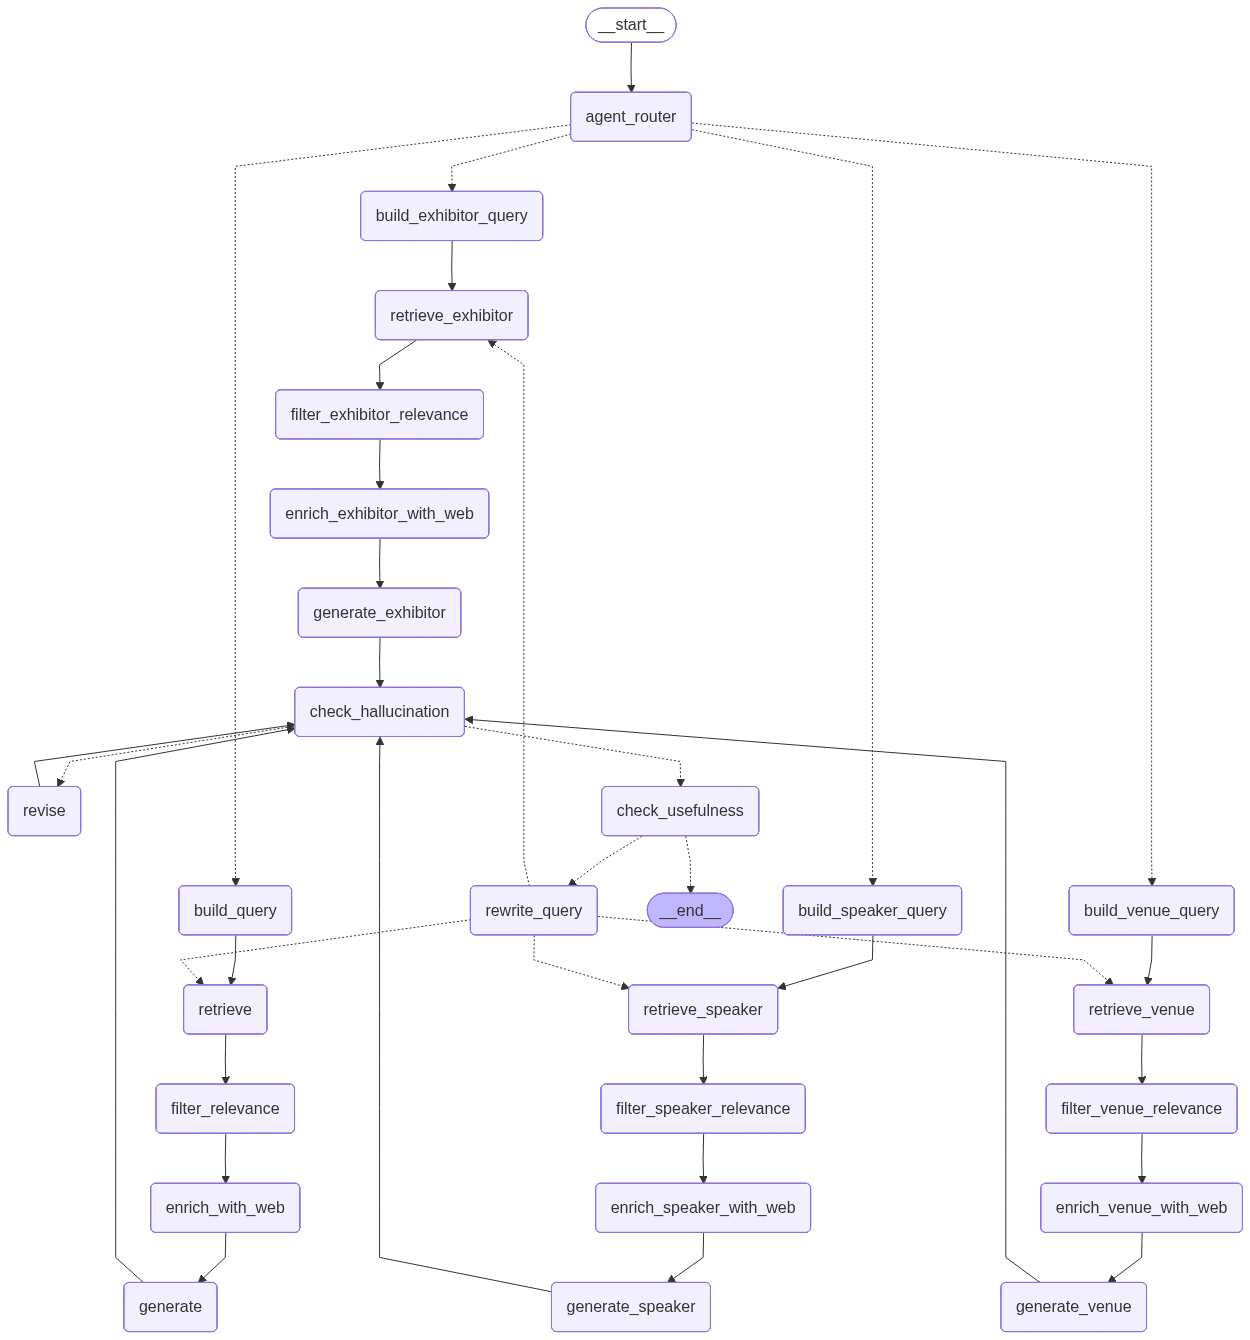

In [21]:
graph

In [22]:
# # ── Initial state ────────────────────────────────────────────────────────────
# initial_state: GraphState = {
#     "user_input":            user_event,
#     "selected_agent":        "",
#     "retrieval_query":       "",
#     "raw_docs":              [],
#     "relevant_docs":         [],
#     "web_profiles":          [],
#     "context":               "",
#     "sponsors_answer":       "",
#     "pricing":               {},
#     "hallucination_verdict": "",
#     "usefulness_verdict":    "",
#     "revise_count":          0,
#     "rewrite_count":         0,
# }

## Cell 10 — Run the Sponsor Agent

In [23]:
# # ── Define your event ────────────────────────────────────────────────────────
# user_event = {
#     "category":      "AI",
#     "event_topic":   "Applied AI in Enterprise",
#     "location":      "India",
#     "audience_size": 2000,
#     "budget":        "50 Lakhs",
#     "objective":     "Find high-fit sponsors with recent activity and strong category relevance"
# }

# # ── Initial state ────────────────────────────────────────────────────────────
# initial_state: GraphState = {
#     "user_input":            user_event,
#     "selected_agent":        "",
#     "retrieval_query":       "",
#     "raw_docs":              [],
#     "relevant_docs":         [],
#     "web_profiles":          [],
#     "context":               "",
#     "sponsors_answer":       "",
#     "pricing":               {},
#     "hallucination_verdict": "",
#     "usefulness_verdict":    "",
#     "revise_count":          0,
#     "rewrite_count":         0,
# }

# print("🚀 Running Unified Agent...\n")
# final_state = graph.invoke(initial_state)

# print("\n" + "="*60)
# print("✅ FINAL RECOMMENDATIONS")
# print("="*60)
# print(f"Selected agent       : {final_state.get('selected_agent', 'UNKNOWN')}")
# display(Markdown(final_state["sponsors_answer"]))
# print("="*60)
# print(f"Hallucination verdict : {final_state['hallucination_verdict']}")
# print(f"Usefulness verdict    : {final_state['usefulness_verdict']}")
# print(f"Revisions done        : {final_state['revise_count']}")
# print(f"Query rewrites done   : {final_state['rewrite_count']}")

## Cell 11 — Try Different Events (sponsor)

In [24]:
# # -- Example 2: Exhibitor request (same graph, different route) --
# event_2 = {
#     "category": "AI",
#     "event_topic": "Applied AI in Enterprise",
#     "location": "Singapore",
#     "audience_size": 5000,
#     "budget": "1 Crore",
#     "objective": "Identify companies that exhibited at similar conferences and cluster them"
# }

# result_2 = graph.invoke({
#     **initial_state,
#     "user_input": event_2,
#     "selected_agent": "",
# })

# print(f"Selected agent: {result_2.get('selected_agent', 'UNKNOWN')}")
# display(Markdown(result_2["sponsors_answer"]))

## Cell 12 — Exhibitor Routing Test Case (assertion)

In [25]:
# # Hard test case: verify router picks EXHIBITOR path
# exhibitor_test_event = {
#     "category": "AI",
#     "event_topic": "Enterprise AI Expo",
#     "location": "Dubai",
#     "audience_size": 8000,
#     "budget": "2 Crore",
#     "objective": "Find and cluster exhibitors for expo booths, startup zone, enterprise pavilion, and dev tools alley"
# }

# exhibitor_test_result = graph.invoke({
#     **initial_state,
#     "user_input": exhibitor_test_event,
#     "selected_agent": "",
# })

# selected = exhibitor_test_result.get("selected_agent", "UNKNOWN")
# print(f"Selected agent: {selected}")

# assert selected == "EXHIBITOR", f"Routing test failed. Expected EXHIBITOR, got {selected}"
# print("Exhibitor routing test passed")

# display(Markdown(exhibitor_test_result["sponsors_answer"]))

## Cell 13 — Venue Routing Test Case (assertion)

In [27]:
initial_state: GraphState = {
    "user_input":            user_event,
    "selected_agent":        "",
    "retrieval_query":       "",
    "raw_docs":              [],
    "relevant_docs":         [],
    "web_profiles":          [],
    "context":               "",
    "sponsors_answer":       "",
    "pricing":               {},
    "hallucination_verdict": "",
    "usefulness_verdict":    "",
    "revise_count":          0,
    "rewrite_count":         0,
}

NameError: name 'user_event' is not defined

In [ ]:
# # Hard test case: verify router picks VENUE path
# venue_test_event = {
#     "category": "AI",
#     "event_topic": "Applied AI Summit",
#     "location": "Bangalore",
#     "audience_size": 5500,
#     "expected_footfall": 6000,
#     "budget": "45 Lakhs",
#     "objective": "Recommend venue options with capacity, pricing, and past event usage"
# }

# venue_test_result = graph.invoke({
#     **initial_state,
#     "user_input": venue_test_event,
#     "selected_agent": "",
# })

# selected = venue_test_result.get("selected_agent", "UNKNOWN")
# print(f"Selected agent: {selected}")

# assert selected == "VENUE", f"Routing test failed. Expected VENUE, got {selected}"
# print("Venue routing test passed")

# display(Markdown(venue_test_result["sponsors_answer"]))

## Cell 14 — main graph (uses pricing_engine.py)

In [28]:
from pricing_engine import PricingEngine


# Lazy singleton so embeddings/model training are done once per kernel session.
pricing_engine = None


def get_pricing_engine() -> PricingEngine:
    global pricing_engine
    if pricing_engine is None:
        pricing_engine = PricingEngine(
            events_path="data/events_v2.csv",
            venues_path="data/venues.csv",
            pricing_tiers_path="data/pricing_tiers.csv",
            pricing_vector_db_path="./pricing_vector_db",
            embedding_model=EMBED_MODEL,
        )
        pricing_engine.load_data()
        pricing_engine.preprocess()   # builds and persists pricing embeddings
        pricing_engine.train_model()
        print("✅ PricingEngine initialized with embeddings + trained models")
    return pricing_engine


# If a rewritten query exists, preserve it in loops instead of rebuilding from scratch.
def _prefer_rewritten_query(state: GraphState) -> str:
    rq = str(state.get("retrieval_query", "")).strip()
    if state.get("rewrite_count", 0) > 0 and rq:
        return rq
    return ""


def build_query(state: GraphState) -> dict:
    rewritten = _prefer_rewritten_query(state)
    if rewritten:
        print(f"[build_query] using rewritten query -> '{rewritten}'")
        return {"retrieval_query": rewritten}

    ui = state["user_input"]
    query = (
        f"{ui.get('category', 'conference')} conference sponsors in {ui.get('location', 'global')} "
        f"audience size {ui.get('audience_size', 'large')} "
        f"budget {ui.get('budget', 'medium')} "
        "recent sponsorships in last 12 months and marketing spend signals"
    )
    print(f"[build_query] -> '{query}'")
    return {"retrieval_query": query}


def build_speaker_query(state: GraphState) -> dict:
    rewritten = _prefer_rewritten_query(state)
    if rewritten:
        print(f"[build_speaker_query] using rewritten query -> '{rewritten}'")
        return {"retrieval_query": rewritten}

    ui = state["user_input"]
    query = (
        f"{ui.get('event_topic', ui.get('category', 'AI'))} speaker artist candidates in {ui.get('location', 'global')} "
        f"audience size {ui.get('audience_size', 'large')} with strong influence and keynote experience"
    )
    print(f"[build_speaker_query] -> '{query}'")
    return {"retrieval_query": query}


def build_exhibitor_query(state: GraphState) -> dict:
    rewritten = _prefer_rewritten_query(state)
    if rewritten:
        print(f"[build_exhibitor_query] using rewritten query -> '{rewritten}'")
        return {"retrieval_query": rewritten}

    ui = state["user_input"]
    query = (
        f"companies that exhibited at {ui.get('category', 'technology')} conferences in {ui.get('location', 'global')} "
        "last 12 months startup enterprise tools individual exhibitor"
    )
    print(f"[build_exhibitor_query] -> '{query}'")
    return {"retrieval_query": query}


def build_venue_query(state: GraphState) -> dict:
    rewritten = _prefer_rewritten_query(state)
    if rewritten:
        print(f"[build_venue_query] using rewritten query -> '{rewritten}'")
        return {"retrieval_query": rewritten}

    ui = state["user_input"]
    query = (
        f"venues in {ui.get('location', 'global')} for {ui.get('category', 'conference')} events "
        f"capacity around {ui.get('audience_size', ui.get('expected_footfall', '2000'))} "
        f"budget {ui.get('budget', 'medium')} setup type and past event usage"
    )
    print(f"[build_venue_query] -> '{query}'")
    return {"retrieval_query": query}


# ---------------- PRICING FLOW ----------------
def build_pricing_query(state: GraphState) -> dict:
    rewritten = _prefer_rewritten_query(state)
    if rewritten:
        print(f"[build_pricing_query] using rewritten query -> '{rewritten}'")
        return {"retrieval_query": rewritten}

    ui = state["user_input"]
    query = (
        f"ticket pricing tiers and conversion for {ui.get('category', 'conference')} events "
        f"in {ui.get('city', ui.get('location', 'global'))} "
        f"audience {ui.get('audience_size', '2000')} budget {ui.get('budget', 'medium')}"
    )
    print(f"[build_pricing_query] -> '{query}'")
    return {"retrieval_query": query}


def retrieve_pricing(state: GraphState) -> dict:
    engine = get_pricing_engine()
    results = engine.pricing_vectordb.similarity_search(state["retrieval_query"], k=12)
    docs = [r.page_content for r in results]
    print(f"[retrieve_pricing] docs={len(docs)}")
    return {"raw_docs": docs}


def filter_pricing_relevance(state: GraphState) -> dict:
    relevant = []
    for doc in state["raw_docs"]:
        prompt = (
            "You are evaluating historical pricing evidence relevance for an event.\n\n"
            f"Target event details: {state['user_input']}\n\n"
            f"Historical record: {doc}\n\n"
            "Is this historical record relevant for ticket pricing and footfall forecasting? Reply ONLY with YES or NO."
        )
        verdict = call_llm(prompt, temperature=0.0)
        if "YES" in verdict.upper():
            relevant.append(doc)

    if not relevant:
        relevant = state["raw_docs"][:6]
        print("[filter_pricing_relevance] fallback -> top 6 raw docs")
    else:
        print(f"[filter_pricing_relevance] relevant={len(relevant)}")

    return {"relevant_docs": relevant, "context": "\n\n".join(relevant)}


def enrich_pricing_with_web(state: GraphState) -> dict:
    ui = state["user_input"]
    city = ui.get("city", ui.get("location", "global"))
    category = ui.get("category", "conference")

    q = (
        f"{category} conference ticket pricing trends {city} conversion rate early bird regular vip "
        "attendance demand signals"
    )
    hits = tavily_search(q, max_results=6)
    joined = " ".join(h.get("snippet", "") for h in hits).lower()

    web_profiles = [{
        "kind": "pricing_market",
        "query": q,
        "hits": hits,
        "pricing_signal": joined.count("price") + joined.count("ticket") + joined.count("pricing"),
        "conversion_signal": joined.count("conversion") + joined.count("sellout") + joined.count("demand"),
        "footfall_signal": joined.count("attendance") + joined.count("footfall") + joined.count("visitors"),
    }]

    print("[enrich_pricing_with_web] pricing web profiles=1")
    return {"web_profiles": web_profiles}


def generate_pricing(state: GraphState) -> dict:
    engine = get_pricing_engine()
    result = engine.optimize_price(state["user_input"])

    prompt = (
        "You are a pricing and footfall strategist.\n\n"
        f"Target event details: {state['user_input']}\n\n"
        "Historical pricing context (from pricing ChromaDB):\n"
        f"{state['context']}\n\n"
        "External market evidence (Tavily):\n"
        f"{json.dumps(state.get('web_profiles', []), ensure_ascii=True, indent=2)}\n\n"
        "Model output (grounded base recommendation):\n"
        f"{json.dumps(result, ensure_ascii=True, indent=2)}\n\n"
        "Task:\n"
        "Produce strict markdown output with:\n"
        "1) Pricing Strategy Table\n"
        "| Tier | Price | Expected Conversion | Expected Tickets Sold | Expected Revenue |\n"
        "2) Forecast Summary Table\n"
        "| Base Price | Expected Attendance | Venue Capacity | Fill Rate | Total Revenue |\n"
        "3) Model Quality Table\n"
        "| Metric | Value |\n"
        "4) 3 short insights grounded ONLY in provided context and model output."
    )

    answer = call_llm(prompt)
    print("[generate_pricing] pricing answer generated")

    return {
        "pricing": result,
        "sponsors_answer": answer,
        "context": state["context"],
        "web_profiles": state.get("web_profiles", []),
    }


# ---------------- COMMUNITY & GTM FLOW ----------------
def build_community_query(state: GraphState) -> dict:
    rewritten = _prefer_rewritten_query(state)
    if rewritten:
        print(f"[build_community_query] using rewritten query -> '{rewritten}'")
        return {"retrieval_query": rewritten}

    ui = state["user_input"]
    query = (
        f"{ui.get('category', 'technology')} communities for event promotion in {ui.get('location', 'global')} "
        f"city {ui.get('city', 'NA')} discord slack linkedin facebook engagement and member size"
    )
    print(f"[build_community_query] -> '{query}'")
    return {"retrieval_query": query}


def retrieve_community(state: GraphState) -> dict:
    results = community_vectordb.similarity_search(state["retrieval_query"], k=15)
    docs = [r.page_content for r in results]
    print(f"[retrieve_community] docs={len(docs)}")
    return {"raw_docs": docs}


def filter_community_relevance(state: GraphState) -> dict:
    relevant = []
    for doc in state["raw_docs"]:
        prompt = (
            "You are evaluating community relevance for go-to-market promotion of an event.\n\n"
            f"Event details: {state['user_input']}\n\n"
            f"Community profile: {doc}\n\n"
            "Is this community relevant for promotion and attendee acquisition? Reply ONLY with YES or NO."
        )
        verdict = call_llm(prompt, temperature=0.0)
        if "YES" in verdict.upper():
            relevant.append(doc)

    if not relevant:
        relevant = state["raw_docs"][:8]
        print("[filter_community_relevance] fallback -> top 8 raw docs")
    else:
        print(f"[filter_community_relevance] relevant={len(relevant)}")

    return {"relevant_docs": relevant, "context": "\n\n".join(relevant)}


def enrich_community_with_web(state: GraphState) -> dict:
    ui = state["user_input"]
    category = ui.get("category", "technology")
    location = ui.get("location", "global")

    market_query = (
        f"best online communities to promote {category} events in {location} "
        "discord slack linkedin facebook cvent eventlocations"
    )
    hits = tavily_search(market_query, max_results=6)
    joined = " ".join(h.get("snippet", "") for h in hits).lower()

    web_profiles = [{
        "kind": "community_gtm_market",
        "query": market_query,
        "hits": hits,
        "platform_signal": joined.count("discord") + joined.count("slack") + joined.count("linkedin") + joined.count("facebook"),
        "eventlisting_signal": joined.count("cvent") + joined.count("eventlocations"),
        "promotion_signal": joined.count("promote") + joined.count("engagement") + joined.count("audience"),
    }]

    print("[enrich_community_with_web] community web profiles=1")
    return {"web_profiles": web_profiles}


def generate_community_plan(state: GraphState) -> dict:
    prompt = (
        "You are a GTM strategist for event growth.\n\n"
        f"Event details: {state['user_input']}\n\n"
        "Internal community context (from ChromaDB):\n"
        f"{state['context']}\n\n"
        "External web evidence:\n"
        f"{json.dumps(state.get('web_profiles', []), ensure_ascii=True, indent=2)}\n\n"
        "Task:\n"
        "1) Identify relevant communities, prioritize Discord first, then Slack/LinkedIn/Facebook.\n"
        "2) Categorize communities by niche.\n"
        "3) Suggest where to promote and message angles.\n"
        "4) Output a distribution plan.\n\n"
        "Output strict markdown tables:\n"
        "A) Community Prioritization Table\n"
        "| Rank | Community | Platform | Niche | Members | Engagement Score | Geo Fit | Why Selected |\n"
        "B) Messaging Strategy Table\n"
        "| Community | Primary Message | CTA | Content Format | Posting Cadence |\n"
        "C) Distribution Plan Table\n"
        "| Week | Platform | Community | Action | Goal Metric |"
    )

    answer = call_llm(prompt)
    print("[generate_community_plan] community GTM plan generated")
    return {"sponsors_answer": answer}


# ---------------- EVENT OPS / EXECUTION FLOW ----------------
def build_event_ops_query(state: GraphState) -> dict:
    rewritten = _prefer_rewritten_query(state)
    if rewritten:
        print(f"[build_event_ops_query] using rewritten query -> '{rewritten}'")
        return {"retrieval_query": rewritten}

    ui = state["user_input"]
    query = (
        f"event agenda scheduling for {ui.get('category', 'conference')} in {ui.get('location', 'global')} "
        f"audience {ui.get('audience_size', '2000')} with session conflicts rooms speakers and time slots"
    )
    print(f"[build_event_ops_query] -> '{query}'")
    return {"retrieval_query": query}


def retrieve_event_ops(state: GraphState) -> dict:
    results = event_ops_vectordb.similarity_search(state["retrieval_query"], k=24)
    docs = [r.page_content for r in results]
    print(f"[retrieve_event_ops] docs={len(docs)}")
    return {"raw_docs": docs}


def filter_event_ops_relevance(state: GraphState) -> dict:
    relevant = []
    for doc in state["raw_docs"]:
        prompt = (
            "You are evaluating agenda scheduling data relevance for event operations.\n\n"
            f"Event details: {state['user_input']}\n\n"
            f"Candidate data: {doc}\n\n"
            "Is this useful for agenda building, overlap/conflict detection, or resource planning? Reply ONLY with YES or NO."
        )
        verdict = call_llm(prompt, temperature=0.0)
        if "YES" in verdict.upper():
            relevant.append(doc)

    if not relevant:
        relevant = state["raw_docs"][:10]
        print("[filter_event_ops_relevance] fallback -> top 10 raw docs")
    else:
        print(f"[filter_event_ops_relevance] relevant={len(relevant)}")

    return {"relevant_docs": relevant, "context": "\n\n".join(relevant)}


def enrich_event_ops_with_web(state: GraphState) -> dict:
    ui = state["user_input"]
    category = ui.get("category", "conference")
    location = ui.get("location", "global")

    q = (
        f"conference agenda planning best practices {category} {location} session conflict detection "
        "room allocation speaker availability"
    )
    hits = tavily_search(q, max_results=6)
    joined = " ".join(h.get("snippet", "") for h in hits).lower()

    web_profiles = [{
        "kind": "event_ops_guidance",
        "query": q,
        "hits": hits,
        "schedule_signal": joined.count("agenda") + joined.count("schedule") + joined.count("timetable"),
        "conflict_signal": joined.count("conflict") + joined.count("overlap") + joined.count("collision"),
        "resource_signal": joined.count("room") + joined.count("speaker") + joined.count("capacity"),
    }]

    print("[enrich_event_ops_with_web] event ops web profiles=1")
    return {"web_profiles": web_profiles}


def generate_event_ops_plan(state: GraphState) -> dict:
    prompt = (
        "You are an event operations planner.\n\n"
        f"Event details: {state['user_input']}\n\n"
        "Internal ops context (sessions, rooms, slots from ChromaDB):\n"
        f"{state['context']}\n\n"
        "External evidence:\n"
        f"{json.dumps(state.get('web_profiles', []), ensure_ascii=True, indent=2)}\n\n"
        "Task:\n"
        "1) Build a practical session agenda/timetable.\n"
        "2) Detect conflicts (time overlaps, speaker clashes, room over-capacity).\n"
        "3) Propose resource planning for rooms, speakers, and timing.\n\n"
        "Output format (mandatory):\n"
        "Final Event Plan:\n\n"
        "Schedule:\n"
        "HH:MM -> Session Name (Room)\n"
        "HH:MM -> Session Name (Room)\n\n"
        "Conflicts:\n"
        "- None OR list each conflict on a new bullet\n\n"
        "Resources:\n"
        "- X rooms allocated\n"
        "- Y volunteers required\n\n"
        "Notes:\n"
        "- High-demand sessions assigned to larger rooms\n"
        "- Buffer times included\n\n"
        "Rules:\n"
        "- Always include Schedule with at least 3 timeline entries when data allows.\n"
        "- Use 24-hour HH:MM times.\n"
        "- If no conflicts exist, write exactly: None\n"
        "- Keep output concise and practical for execution teams.\n"
    )

    answer = call_llm(prompt)
    print("[generate_event_ops_plan] event ops plan generated")
    return {"sponsors_answer": answer}


# ---------------- MASTER ROUTER ----------------
def agent_router(state: GraphState) -> dict:
    ui = state["user_input"]
    prompt = (
        "You are an intent router for event-planning agents.\n\n"
        f"User request: {ui}\n\n"
        "Choose exactly one agent:\n"
        "- SPONSOR: sponsors, sponsorship proposal, sponsor prioritization\n"
        "- SPEAKER: speakers, artists, agenda mapping, thought leaders\n"
        "- EXHIBITOR: exhibitors, expo booths, companies to invite for exhibition\n"
        "- VENUE: venue shortlisting, city, capacity, footfall, budget\n"
        "- PRICING: ticket tiers, conversion, attendance forecast, revenue optimization\n"
        "- COMMUNITY: community discovery, GTM, promotion distribution plan\n"
        "- EVENT_OPS: agenda builder, conflict detection, room/speaker/time resource planning\n\n"
        "Reply with ONLY one token: SPONSOR or SPEAKER or EXHIBITOR or VENUE or PRICING or COMMUNITY or EVENT_OPS"
    )
    decision = call_llm(prompt, temperature=0.0).upper().strip()
    if "EVENT_OPS" in decision or "EVENT OPS" in decision or "OPS" in decision:
        selected_agent = "EVENT_OPS"
    elif "COMMUNITY" in decision:
        selected_agent = "COMMUNITY"
    elif "PRICING" in decision:
        selected_agent = "PRICING"
    elif "SPEAKER" in decision:
        selected_agent = "SPEAKER"
    elif "EXHIBITOR" in decision:
        selected_agent = "EXHIBITOR"
    elif "VENUE" in decision:
        selected_agent = "VENUE"
    else:
        selected_agent = "SPONSOR"
    print(f"[agent_router] selected -> {selected_agent}")
    return {"selected_agent": selected_agent}


def route_after_agent_router(state: GraphState) -> str:
    agent = state.get("selected_agent", "SPONSOR").upper()
    if "EVENT_OPS" in agent:
        return "event_ops_subgraph"
    if "COMMUNITY" in agent:
        return "community_subgraph"
    if "PRICING" in agent:
        return "pricing_subgraph"
    if "SPEAKER" in agent:
        return "speaker_subgraph"
    if "EXHIBITOR" in agent:
        return "exhibitor_subgraph"
    if "VENUE" in agent:
        return "venue_subgraph"
    return "sponsor_subgraph"


def route_after_rewrite(state: GraphState) -> str:
    agent = state.get("selected_agent", "SPONSOR").upper()
    if "EVENT_OPS" in agent:
        return "event_ops_subgraph"
    if "COMMUNITY" in agent:
        return "community_subgraph"
    if "PRICING" in agent:
        return "pricing_subgraph"
    if "SPEAKER" in agent:
        return "speaker_subgraph"
    if "EXHIBITOR" in agent:
        return "exhibitor_subgraph"
    if "VENUE" in agent:
        return "venue_subgraph"
    return "sponsor_subgraph"


# ---------------- SUBGRAPH BUILDERS ----------------
def build_sponsor_subgraph():
    sg = StateGraph(GraphState)
    sg.add_node("build_query", build_query)
    sg.add_node("retrieve", retrieve)
    sg.add_node("filter_relevance", filter_relevance)
    sg.add_node("enrich_with_web", enrich_with_web)
    sg.add_node("generate", generate)
    sg.set_entry_point("build_query")
    sg.add_edge("build_query", "retrieve")
    sg.add_edge("retrieve", "filter_relevance")
    sg.add_edge("filter_relevance", "enrich_with_web")
    sg.add_edge("enrich_with_web", "generate")
    sg.add_edge("generate", END)
    return sg.compile()


def build_speaker_subgraph():
    sg = StateGraph(GraphState)
    sg.add_node("build_speaker_query", build_speaker_query)
    sg.add_node("retrieve_speaker", retrieve_speaker)
    sg.add_node("filter_speaker_relevance", filter_speaker_relevance)
    sg.add_node("enrich_speaker_with_web", enrich_speaker_with_web)
    sg.add_node("generate_speaker", generate_speaker)
    sg.set_entry_point("build_speaker_query")
    sg.add_edge("build_speaker_query", "retrieve_speaker")
    sg.add_edge("retrieve_speaker", "filter_speaker_relevance")
    sg.add_edge("filter_speaker_relevance", "enrich_speaker_with_web")
    sg.add_edge("enrich_speaker_with_web", "generate_speaker")
    sg.add_edge("generate_speaker", END)
    return sg.compile()


def build_exhibitor_subgraph():
    sg = StateGraph(GraphState)
    sg.add_node("build_exhibitor_query", build_exhibitor_query)
    sg.add_node("retrieve_exhibitor", retrieve_exhibitor)
    sg.add_node("filter_exhibitor_relevance", filter_exhibitor_relevance)
    sg.add_node("enrich_exhibitor_with_web", enrich_exhibitor_with_web)
    sg.add_node("generate_exhibitor", generate_exhibitor)
    sg.set_entry_point("build_exhibitor_query")
    sg.add_edge("build_exhibitor_query", "retrieve_exhibitor")
    sg.add_edge("retrieve_exhibitor", "filter_exhibitor_relevance")
    sg.add_edge("filter_exhibitor_relevance", "enrich_exhibitor_with_web")
    sg.add_edge("enrich_exhibitor_with_web", "generate_exhibitor")
    sg.add_edge("generate_exhibitor", END)
    return sg.compile()


def build_venue_subgraph():
    sg = StateGraph(GraphState)
    sg.add_node("build_venue_query", build_venue_query)
    sg.add_node("retrieve_venue", retrieve_venue)
    sg.add_node("filter_venue_relevance", filter_venue_relevance)
    sg.add_node("enrich_venue_with_web", enrich_venue_with_web)
    sg.add_node("generate_venue", generate_venue)
    sg.set_entry_point("build_venue_query")
    sg.add_edge("build_venue_query", "retrieve_venue")
    sg.add_edge("retrieve_venue", "filter_venue_relevance")
    sg.add_edge("filter_venue_relevance", "enrich_venue_with_web")
    sg.add_edge("enrich_venue_with_web", "generate_venue")
    sg.add_edge("generate_venue", END)
    return sg.compile()


def build_pricing_subgraph():
    sg = StateGraph(GraphState)
    sg.add_node("build_pricing_query", build_pricing_query)
    sg.add_node("retrieve_pricing", retrieve_pricing)
    sg.add_node("filter_pricing_relevance", filter_pricing_relevance)
    sg.add_node("enrich_pricing_with_web", enrich_pricing_with_web)
    sg.add_node("generate_pricing", generate_pricing)
    sg.set_entry_point("build_pricing_query")
    sg.add_edge("build_pricing_query", "retrieve_pricing")
    sg.add_edge("retrieve_pricing", "filter_pricing_relevance")
    sg.add_edge("filter_pricing_relevance", "enrich_pricing_with_web")
    sg.add_edge("enrich_pricing_with_web", "generate_pricing")
    sg.add_edge("generate_pricing", END)
    return sg.compile()


def build_community_subgraph():
    sg = StateGraph(GraphState)
    sg.add_node("build_community_query", build_community_query)
    sg.add_node("retrieve_community", retrieve_community)
    sg.add_node("filter_community_relevance", filter_community_relevance)
    sg.add_node("enrich_community_with_web", enrich_community_with_web)
    sg.add_node("generate_community_plan", generate_community_plan)
    sg.set_entry_point("build_community_query")
    sg.add_edge("build_community_query", "retrieve_community")
    sg.add_edge("retrieve_community", "filter_community_relevance")
    sg.add_edge("filter_community_relevance", "enrich_community_with_web")
    sg.add_edge("enrich_community_with_web", "generate_community_plan")
    sg.add_edge("generate_community_plan", END)
    return sg.compile()


def build_event_ops_subgraph():
    sg = StateGraph(GraphState)
    sg.add_node("build_event_ops_query", build_event_ops_query)
    sg.add_node("retrieve_event_ops", retrieve_event_ops)
    sg.add_node("filter_event_ops_relevance", filter_event_ops_relevance)
    sg.add_node("enrich_event_ops_with_web", enrich_event_ops_with_web)
    sg.add_node("generate_event_ops_plan", generate_event_ops_plan)
    sg.set_entry_point("build_event_ops_query")
    sg.add_edge("build_event_ops_query", "retrieve_event_ops")
    sg.add_edge("retrieve_event_ops", "filter_event_ops_relevance")
    sg.add_edge("filter_event_ops_relevance", "enrich_event_ops_with_web")
    sg.add_edge("enrich_event_ops_with_web", "generate_event_ops_plan")
    sg.add_edge("generate_event_ops_plan", END)
    return sg.compile()


sponsor_subgraph = build_sponsor_subgraph()
speaker_subgraph = build_speaker_subgraph()
exhibitor_subgraph = build_exhibitor_subgraph()
venue_subgraph = build_venue_subgraph()
pricing_subgraph = build_pricing_subgraph()
community_subgraph = build_community_subgraph()
event_ops_subgraph = build_event_ops_subgraph()


# ---------------- MASTER GRAPH WITH SUBGRAPHS ----------------
builder = StateGraph(GraphState)

builder.add_node("agent_router", agent_router)

# Agent subgraphs
builder.add_node("sponsor_subgraph", sponsor_subgraph)
builder.add_node("speaker_subgraph", speaker_subgraph)
builder.add_node("exhibitor_subgraph", exhibitor_subgraph)
builder.add_node("venue_subgraph", venue_subgraph)
builder.add_node("pricing_subgraph", pricing_subgraph)
builder.add_node("community_subgraph", community_subgraph)
builder.add_node("event_ops_subgraph", event_ops_subgraph)

# Shared self-RAG quality nodes
builder.add_node("check_hallucination", check_hallucination)
builder.add_node("revise", revise)
builder.add_node("check_usefulness", check_usefulness)
builder.add_node("rewrite_query", rewrite_query)

builder.set_entry_point("agent_router")

builder.add_conditional_edges(
    "agent_router",
    route_after_agent_router,
    {
        "sponsor_subgraph": "sponsor_subgraph",
        "speaker_subgraph": "speaker_subgraph",
        "exhibitor_subgraph": "exhibitor_subgraph",
        "venue_subgraph": "venue_subgraph",
        "pricing_subgraph": "pricing_subgraph",
        "community_subgraph": "community_subgraph",
        "event_ops_subgraph": "event_ops_subgraph",
    }
)

# Every subgraph joins shared self-RAG checks
builder.add_edge("sponsor_subgraph", "check_hallucination")
builder.add_edge("speaker_subgraph", "check_hallucination")
builder.add_edge("exhibitor_subgraph", "check_hallucination")
builder.add_edge("venue_subgraph", "check_hallucination")
builder.add_edge("pricing_subgraph", "check_hallucination")
builder.add_edge("community_subgraph", "check_hallucination")
builder.add_edge("event_ops_subgraph", "check_hallucination")

# Shared self-RAG loops
builder.add_edge("revise", "check_hallucination")

builder.add_conditional_edges(
    "check_hallucination",
    route_after_hallucination_check,
    {
        "check_usefulness": "check_usefulness",
        "revise": "revise",
    }
)

builder.add_conditional_edges(
    "check_usefulness",
    route_after_usefulness_check,
    {
        "rewrite_query": "rewrite_query",
        END: END,
    }
)

builder.add_conditional_edges(
    "rewrite_query",
    route_after_rewrite,
    {
        "sponsor_subgraph": "sponsor_subgraph",
        "speaker_subgraph": "speaker_subgraph",
        "exhibitor_subgraph": "exhibitor_subgraph",
        "venue_subgraph": "venue_subgraph",
        "pricing_subgraph": "pricing_subgraph",
        "community_subgraph": "community_subgraph",
        "event_ops_subgraph": "event_ops_subgraph",
    }
)

graph = builder.compile()
print("✅ Master LangGraph compiled with subgraphs + shared self-RAG + community + event ops")

✅ Master LangGraph compiled with subgraphs + shared self-RAG + community + event ops


## pricing chk

In [29]:
# # Pricing routing and self-RAG validation test
# pricing_test_event = {
#     "category": "AI",
#     "location": "India",
#     "city": "Bangalore",
#     "audience_size": 2000,
#     "budget": 5000000,
#     "objective": "Optimize ticket pricing tiers and forecast attendance/revenue"
# }

# pricing_state = {
#     **initial_state,
#     "user_input": pricing_test_event,
#     "input": pricing_test_event,
#     "selected_agent": "",
# }

# pricing_result = graph.invoke(pricing_state)

# print("Selected agent:", pricing_result.get("selected_agent", "UNKNOWN"))
# assert pricing_result.get("selected_agent") == "PRICING", "Expected PRICING route"
# assert "pricing" in pricing_result, "Expected structured pricing output in state['pricing']"

# print("Hallucination verdict:", pricing_result.get("hallucination_verdict", "N/A"))
# print("Usefulness verdict:", pricing_result.get("usefulness_verdict", "N/A"))
# print("Revisions done:", pricing_result.get("revise_count", 0))
# print("Query rewrites done:", pricing_result.get("rewrite_count", 0))

# metrics = pricing_result.get("pricing", {}).get("model_metrics", {})
# print("Attendance R2:", round(metrics.get("attendance_r2", 0.0), 4))
# print("Attendance precision (<=10% error):", round(metrics.get("attendance_precision_within_10pct", 0.0), 4))
# print("Conversion R2:", round(metrics.get("conversion_r2", 0.0), 4))
# print("Conversion precision (<=10% error):", round(metrics.get("conversion_precision_within_10pct", 0.0), 4))

# display(Markdown(pricing_result.get("sponsors_answer", "No output generated")))

## Cell 15 — Community & GTM Routing Test Case (assertion)

In [30]:
# # Community & GTM routing validation
# community_test_event = {
#     "category": "AI/ML",
#     "location": "India",
#     "city": "Bangalore",
#     "audience_size": 3000,
#     "budget": "35 Lakhs",
#     "objective": "Identify relevant Discord first, then Slack/LinkedIn/Facebook communities and output GTM distribution plan"
# }

# community_state = {
#     **initial_state,
#     "user_input": community_test_event,
#     "selected_agent": "",
# }

# community_result = graph.invoke(community_state)

# print("Selected agent:", community_result.get("selected_agent", "UNKNOWN"))
# assert community_result.get("selected_agent") == "COMMUNITY", "Expected COMMUNITY route"

# print("Hallucination verdict:", community_result.get("hallucination_verdict", "N/A"))
# print("Usefulness verdict:", community_result.get("usefulness_verdict", "N/A"))
# print("Revisions done:", community_result.get("revise_count", 0))
# print("Query rewrites done:", community_result.get("rewrite_count", 0))

# display(Markdown(community_result.get("sponsors_answer", "No output generated")))

## event ops testig

<!-- ## event ops testing -->

In [33]:
# Event Ops / Execution routing validation
event_ops_test_event = {
    "category": "AI Summit",
    "location": "Bangalore",
    "city": "Bangalore",
    "audience_size": 3000,
    "budget": "40 Lakhs",
    "objective": "Build agenda, detect overlapping sessions, and plan room/speaker/time allocation"
}

# Use initial_state when available; otherwise fall back to an empty base state.
base_state = globals().get("initial_state", {})

# Refresh/recover Event Ops vector store handle if the backing Chroma collection is stale.
try:
    _ = event_ops_vectordb._collection.count()
except Exception:
    if "event_ops_docs" in globals() and event_ops_docs:
        event_ops_vectordb = Chroma.from_documents(
            documents=event_ops_docs,
            embedding=embedding_fn,
            persist_directory=EVENT_OPS_VECTOR_DB_PATH,
        )
        print(f"[event_ops_test] rebuilt Event Ops DB with {len(event_ops_docs)} docs")
    else:
        event_ops_vectordb = Chroma(
            persist_directory=EVENT_OPS_VECTOR_DB_PATH,
            embedding_function=embedding_fn,
        )
        try:
            _ = event_ops_vectordb._collection.count()
        except Exception as exc:
            raise RuntimeError(
                "Event Ops collection is missing. Run the ingestion/build vector DB cell before this test."
            ) from exc

event_ops_state = {
    **base_state,
    "user_input": event_ops_test_event,
    "selected_agent": "",
}

event_ops_result = graph.invoke(event_ops_state)

print("Selected agent:", event_ops_result.get("selected_agent", "UNKNOWN"))
assert event_ops_result.get("selected_agent") == "EVENT_OPS", "Expected EVENT_OPS route"

print("Hallucination verdict:", event_ops_result.get("hallucination_verdict", "N/A"))
print("Usefulness verdict:", event_ops_result.get("usefulness_verdict", "N/A"))
print("Revisions done:", event_ops_result.get("revise_count", 0))
print("Query rewrites done:", event_ops_result.get("rewrite_count", 0))

display(Markdown(event_ops_result.get("sponsors_answer", "No output generated")))

[agent_router] selected -> EVENT_OPS
[build_event_ops_query] -> 'event agenda scheduling for AI Summit in Bangalore audience 3000 with session conflicts rooms speakers and time slots'
[retrieve_event_ops] docs=24


KeyboardInterrupt: 